In [1]:
import matplotlib.pyplot as plt
import time
import numpy as np

# Import pyRTC Core classes and OOPAO interface
import sys

tmp = sys.stdout
# from pyRTC import *
from pyRTC.hardware.OOPAOInterface import OOPAOInterface
from pyRTC.SlopesProcess import SlopesProcess
from pyRTC.Loop import Loop
from pyRTC.utils import read_yaml_file

sys.stdout = tmp
# from pyRTC.hardware.OOPAOInterface import OOPAOInterface

In [2]:
conf = read_yaml_file("shwfs_OOPAO_config.yaml")

# Split into component sections
confLoop = conf["loop"]
confWFS = conf["wfs"]
confWFC = conf["wfc"]
confPSF = conf["psf"]
confSlopes = conf["slopes"]

print(confLoop)
print(confWFS)
print(confWFC)
print(confPSF)
print(confSlopes)

{'gain': 0.1, 'leakyGain': 0.01, 'numDroppedModes': 0, 'pokeAmp': 9.5e-07, 'numItersIM': 1, 'affinity': 2, 'method': 'push-pull', 'functions': ['leakyIntegrator']}
{'name': 'OOPAOWFS', 'width': 350, 'height': 350, 'darkCount': 1000, 'integration': 50, 'affinity': 3, 'functions': ['expose']}
{'name': 'OOPAOWFC', 'numActuators': 97, 'numModes': 95, 'flatFile': '', 'saveFile': 'flat.npy', 'm2cFile': '', 'affinity': 3, 'commandCap': 0.8, 'hardwareDelay': 0.001, 'frameDelay': 0, 'functions': ['sendToHardware']}
{'name': 'OOPAOPSF', 'index': 0, 'width': 200, 'height': 200, 'darkCount': 10, 'integration': 10, 'wavelengthNm': 950, 'affinity': 3, 'functions': ['expose', 'integrate', 'computeStrehl']}
{'type': 'SHWFS', 'signalType': 'slopes', 'affinity': 4, 'flatNorm': True, 'lensletsX': 25, 'lensletsY': 25, 'pixelsPerLenslet': 14, 'subApSpacing': 14, 'subApOffsetX': 0, 'subApOffsetY': 0, 'functions': ['computeSignal']}


In [3]:
param = dict()

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% ATMOSPHERE PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

param["r0"] = 0.15  # value of r0 in the visible in [m]
param["L0"] = 30  # value of L0 in the visible in [m]
param["fractionnalR0"] = [0.45, 0.1, 0.1, 0.25, 0.1]  # Cn2 profile
param["windSpeed"] = [
    10,
    12,
    11,
    15,
    20,
]  # wind speed of the different layers in [m.s-1]
param["windDirection"] = [
    0,
    72,
    144,
    216,
    288,
]  # wind direction of the different layers in [degrees]
param["altitude"] = [
    0,
    1000,
    5000,
    10000,
    12000,
]  # altitude of the different layers in [m]

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% WFS PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

param["nSubaperture"] = confSlopes["lensletsX"]
# number of subaperture along the telescope diameter
param["nPixelPerSubap"] = confSlopes[
    "pixelsPerLenslet"
]  # sampling of the PWFS subapertures

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% M1 PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

param["diameter"] = 8  # diameter in [m]
param["resolution"] = (
    param["nSubaperture"] * param["nPixelPerSubap"]
)  # resolution of the telescope driven by the PWFS
param["sizeSubaperture"] = (
    param["diameter"] / param["nSubaperture"]
)  # size of a sub-aperture projected in the M1 space
param["samplingTime"] = 1 / 300  # loop sampling time in [s]
param["centralObstruction"] = 0.112  # central obstruction in percentage of the diameter
param["nMissingSegments"] = 0  # number of missing segments on the M1 pupil
param["m1_reflectivity"] = 1  # reflectivity of the 798 segments

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% NGS PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

param["magnitude"] = 8  # magnitude of the guide star
param["opticalBand"] = "R"  # optical band of the guide star
param["sourceBand"] = "J"

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DM PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# ALPAO 97 DM Layout
xx, yy = np.meshgrid(np.arange(11), np.arange(11))
layout = np.sqrt((xx - 5) ** 2 + (yy - 5) ** 2) < 5.5
coordinates = np.array(np.nonzero(layout)).T.astype(np.float64)

# need coordinates in [D/2, D/2] range instead of [0, 10]
coordinates -= 5.0
coordinates *= (param["diameter"] / 2.0) / 5.0

param["nActuator"] = 97  # number of actuators
param["mechanicalCoupling"] = 0.35
param["isM4"] = False  # tag for the deformable mirror class
param["dm_coordinates"] = coordinates  # tag for the eformable mirror class
param["dm_layout"] = layout

# mis-registrations
param["shiftX"] = 0  # shift X of the DM in pixel size units ( tel.D/tel.resolution )
param["shiftY"] = 0  # shift Y of the DM in pixel size units ( tel.D/tel.resolution )
param["rotationAngle"] = 0  # rotation angle of the DM in [degrees]
param["anamorphosisAngle"] = 0  # anamorphosis angle of the DM in [degrees]
param["radialScaling"] = 0  # radial scaling in percentage of diameter
param["tangentialScaling"] = 0  # tangential scaling in percentage of diameter

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% WFS PROPERTIES %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

param["modulation"] = (
    5  # modulation radius in ratio of wavelength over telescope diameter
)
param["n_pix_separation"] = 4  # separation ratio between the PWFS pupils
param["psfCentering"] = (
    False  # centering of the FFT and of the PWFS mask on the 4 central pixels
)
param["lightThreshold"] = 0.1  # light threshold to select the valid pixels
param["postProcessing"] = "slopesMaps"  # post-processing of the PWFS signals

###%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% OUTPUT DATA %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# name of the system
param["name"] = (
    "VLT_"
    + param["opticalBand"]
    + "_band_"
    + str(param["nSubaperture"])
    + "x"
    + str(param["nSubaperture"])
)

# location of the calibration data
param["pathInput"] = "data_calibration/"

# location of the output data
param["pathOutput"] = "data_cl/"

In [4]:
# from pyRTC.Pipeline import clear_shms

# shm_names = [
#     "wfs",
#     "wfsRaw",
#     "wfc",
#     "wfc2D",
#     "signal",
#     "signal2D",
#     "psfShort",
#     "psfLong",
# ]
# clear_shms(shm_names)

In [ ]:
# Create OOPAO simulation interface
sim = OOPAOInterface(conf=conf, param=param)

# Extract references to the simulated hardware
wfs, dm, psf = sim.get_hardware()


------------ Telescope -------------
Diameter [m]             |   8.00   
Resolution [px]          |   350    
Pixel size [m]           |   0.02   
Surface [m²]             |  49.64   
Central obstruction [%]  |    11    
Pixels in pupil          |  95016   
Field of view [arcsec]   |   0.00   
------------------------------------


------------ Telescope -------------
Diameter [m]             |   8.00   
Resolution [px]          |   350    
Pixel size [m]           |   0.02   
Surface [m²]             |  49.64   
Central obstruction [%]  |    11    
Pixels in pupil          |  95016   
Field of view [arcsec]   |   0.00   
------------------------------------


------------- Source --------------
Source                   |   NGS   
Wavelength [m]           | 1.2e-06 
Zenith [arcsec]          |  0.00   
Azimuth [°]              |  0.00   
Altitude [m]             |   inf   
Magnitude                |  8.00   
Flux [photon/m²/s]       | 3.3e+06 
Coordinates [arcsec,deg] | [0,0]
--------

Exception in thread Thread-17 (work):
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/dev/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/opt/homebrew/anaconda3/envs/dev/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/homebrew/anaconda3/envs/dev/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/robin/Documents/Code/darren/pyRTC/pyRTC/Pipeline.py", line 53, in work
    workFunction()
  File "/Users/robin/Documents/Code/darren/pyRTC/pyRTC/hardware/OOPAOInterface.py", line 123, in expose
    super().expose()
  File "/Users/robin/Documents/Code/darren/pyRTC/pyRTC/ScienceCamera.py", line 210, in expose
    self.psfShort.write(self.data.astype(self.imageDType) - self.dark)
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^~~~~~~~~~~
ValueError: operands could not be broadcast together with s

OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!
OOPAO Warning: 
Some subapertures are giving nan values!


In [6]:
from OOPAO.calibration.compute_KL_modal_basis import compute_KL_basis

NUM_MODES = confWFC["numModes"]  # 97
M2C_KL = compute_KL_basis(sim.tel, sim.atm, sim.dm)
dm.setM2C(M2C_KL[:, :NUM_MODES])

TIME ELAPSED: 1 sec. COMPLETED: 100 %
NMAX =  96
RMS opd error = [[3.75257070e-07 4.10545341e-07 4.10545341e-07]]
RMS Positions = [[7.14140619e-07 2.44631502e-06 2.44631502e-06]]
MAX Positions = [[4.23529013e-06 7.92186143e-06 7.92186143e-06]]
KL WITH DOUBLE DIAGONALISATION: COVARIANCE ERROR =  4.1187874435388095e-14


In [7]:
slopes = SlopesProcess(conf=confSlopes)
loop = Loop(conf=confLoop)

Thread computeSignal: Priority set to REALTIME
Opening Existing Shared Memory Object wfs_meta
Closing wfs_meta
Opening Existing Shared Memory Object wfs
Opening Existing Shared Memory Object wfs_meta
subApSpacing: 14
numRegions: 25
offsetX: 0
offsetY: 0
signalSize: 1250
signalShape: (np.int64(1250),)
signalDType: <class 'numpy.float32'>
Opening Existing Shared Memory Object signal
Opening Existing Shared Memory Object signal_meta
Opening Existing Shared Memory Object signal2D
Opening Existing Shared Memory Object signal2D_meta
Thread leakyIntegrator: Priority set to REALTIME
Opening Existing Shared Memory Object signal_meta
Closing signal_meta
Opening Existing Shared Memory Object signal
Opening Existing Shared Memory Object signal_meta
Opening Existing Shared Memory Object wfc_meta
Closing wfc_meta
Opening Existing Shared Memory Object wfc
Opening Existing Shared Memory Object wfc_meta


In [8]:
dm.numModes

95

DM OPD shape: (350, 350, 97)


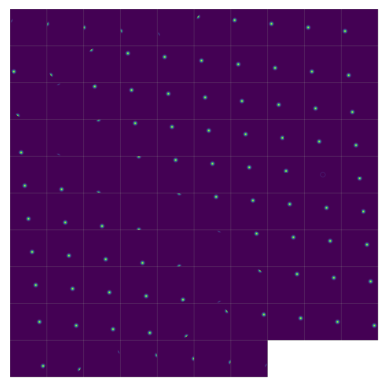

In [9]:
from OOPAO.tools.displayTools import cl_plot, displayMap

dm.start()
dm.flatten()  # start from flat

wfs.start()
slopes.start()

print("DM OPD shape:", sim.dm.OPD.shape)

psf.start()
dm.flatten()
# slopes.plotPupils()  # quick visual sanity check

displayMap(sim.tel.OPD)

In [10]:
dm.flatten()

In [11]:
# Remove atmosphere for clean IM
sim.removeAtmosphere()

# Optional: reference PSF for Strehl calc (if implemented)
if hasattr(psf, "takeModelPSF"):
    psf.takeModelPSF()

# IM settings from YAML (pokeAmp=9.5e-7, method=push-pull, numItersIM=1)
loop.pokeAmp = confLoop["pokeAmp"]
loop.computeIM()  # blocking; fills IM internally

# Restore atmosphere
sim.addAtmosphere()

# Visualize
plt.imshow(sim.dm.OPD)
plt.colorbar()
plt.title("DM OPD (post-IM)")
plt.show()
loop.plotIM()
plt.show()

# (Optional) Save IM/CM for reuse
IM = loop.getIM()
utils.ensure_dir("./cal")
np.save("./cal/IM_SHWFS.npy", IM)
try:
    CM = loop.getCM()
except AttributeError:
    CM = utils.pinv(IM, rcond=1e-3)
np.save("./cal/CM_SHWFS.npy", CM)

Telescope and Atmosphere separated!
Telescope and Atmosphere separated!


KeyboardInterrupt: 

In [ ]:
dm.flatten()
time.sleep(1e-2)

loop.setGain(confLoop["gain"])  # 0.1
loop.start()

time.sleep(10)  # run for 10 seconds

loop.stop()
dm.flatten()

In [ ]:
# Science camera PSF (current frame)
plt.imshow(psf.data)
plt.colorbar()
plt.title("Science Camera PSF (Current Frame)")
plt.show()

# Normalized PSF from OOPAO
plt.imshow(psf.tel.PSF_norma)
plt.colorbar()
plt.title("Normalized PSF (OOPAO)")
plt.show()

# Final DM optical path difference (OPD)
plt.imshow(sim.dm.OPD)
plt.colorbar()
plt.title("Final DM Shape (OPD Map)")
plt.show()

# WFS 2D signal (SH slopes maps concatenated)
plt.imshow(sim.wfs.signal_2D)
plt.colorbar()
plt.title("WFS 2D Signal (SHWFS)")
plt.show()

# Processed slopes output (SlopesProcess)
plt.imshow(slopes.signal2D.read_noblock())
plt.colorbar()
plt.title("Processed Slopes (2D)")
plt.show()